Titanic Accident Survival Predication Using Logistic Regression
<!-- 1. One column?
   → Category → countplot
   → Number → histogram

2. Two columns?
   → Both numbers → scatter
   → Category + number → boxplot
   → Both category → countplot (hue)

3. Want relationships between many numbers?
   → heatmap -->

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score


In [2]:
df =pd.read_csv('Titanic-Dataset.csv')
print(df.head())
print(df.isnull().sum().sum())


   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  
86

C:\Users\shara\AppData\Local\Temp\ipykernel_27740\2799028141.py:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:green'` for the same effect.

  sns.countplot(x='Survived', hue='Sex', data=df, color='green')


<Axes: xlabel='Pclass', ylabel='Fare'>

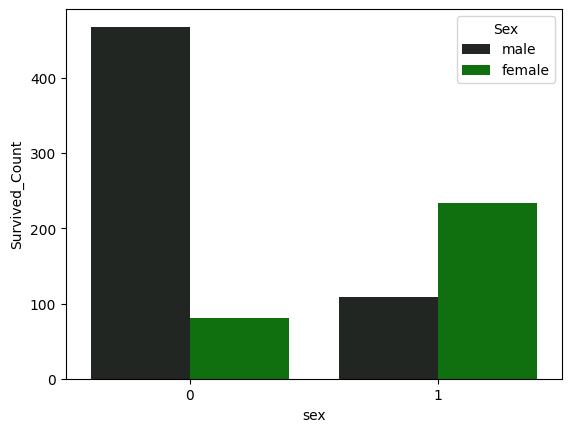

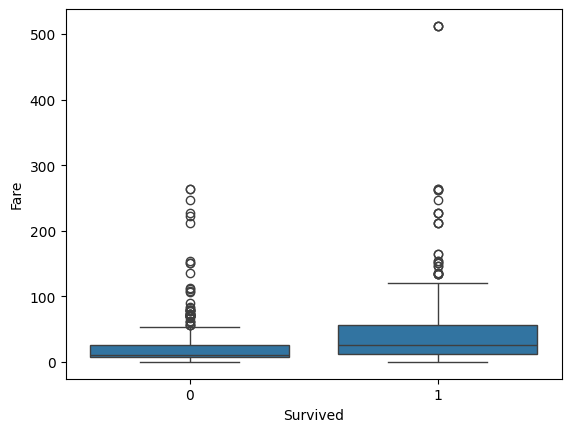

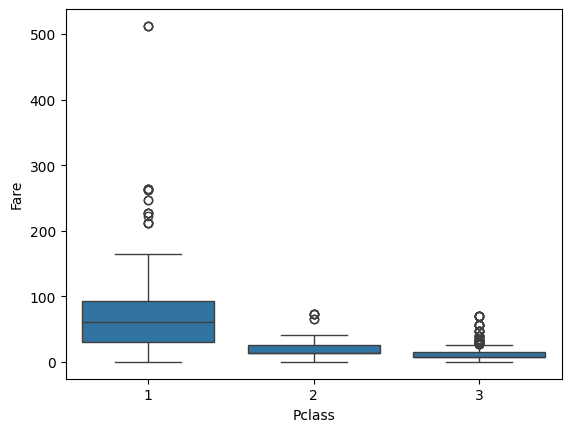

In [3]:
# plt.hist(df['Survived'])
sns.countplot(x='Survived', hue='Sex', data=df, color='green')
plt.xlabel('sex')
plt.ylabel('Survived_Count')
plt.figure()
sns.boxplot(x='Survived', y='Fare', data=df)
plt.figure()

sns.boxplot(x='Pclass', y='Fare', data=df)


In [4]:
df.corr(numeric_only=True)['Survived']

PassengerId   -0.005007
Survived       1.000000
Pclass        -0.338481
Age           -0.077221
SibSp         -0.035322
Parch          0.081629
Fare           0.257307
Name: Survived, dtype: float64

In [5]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

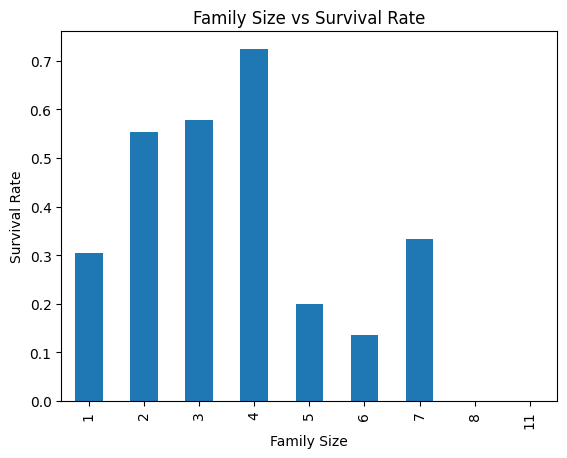

In [6]:

family_survival = df.groupby('FamilySize')['Survived'].mean()

plt.figure()
family_survival.plot(kind='bar')

plt.title("Family Size vs Survival Rate")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate")

plt.show()

In [7]:
X=df[['Pclass','Sex','Age','FamilySize','Fare','Embarked']]
Y=df['Survived']


X_train , X_test ,Y_train, Y_test =train_test_split(X,Y,test_size=0.2,random_state=42)

mean_cols = ['Age']
median_cols = ['Fare']
scale_cols = ['FamilySize']  

cat_cols = ['Pclass', 'Sex', 'Embarked']




In [8]:
#   preprocessing numerical values using pipelines

# Mean Imputation
mean_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Median Imputation
median_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

# No Imputation (just scaling)
scale_pipeline = Pipeline([
    ('scaler', StandardScaler())
])


In [9]:
#   preprocessing categorical values using pipelines

cat_pipeline =Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

In [10]:
preprocessor = ColumnTransformer([
    ('mean_num', mean_pipeline, mean_cols),
    ('median_num', median_pipeline, median_cols),
    ('scaled_num', scale_pipeline, scale_cols),
    ('cat', cat_pipeline, cat_cols)
])

In [11]:
model_pipeline =Pipeline([
    ('processing',preprocessor),
    ('model',LogisticRegression())
])

In [12]:
model_pipeline.fit(X_train,Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('processing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('mean_num', ...), ('median_num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different 

In [13]:
Y_pred = model_pipeline.predict(X_test)

In [14]:
print("Accuracy:", accuracy_score(Y_test, Y_pred)*100)

Accuracy: 79.88826815642457


In [ ]:

new_data = pd.DataFrame({
    'Pclass': [3],
    'Sex': ['female'],
    'Age': [22],
    'Fare': [7.25],
    'Embarked': ['S'],
    'FamilySize': [3]
})

# Predict
prediction = model_pipeline.predict(new_data)

if prediction == 0:
 print("Did NOT survive")
else:
 print("survived")


Did NOT survive
